# 🔋 Week 2 — Shallow ML Baselines
## Robust Electricity Theft Detection Under Data-Poisoning Attacks

**Student:** Surekha Suresh | C00317211  
**Supervisor:** Milu Philip | SETU Carlow  

### Week 2 Objectives
- [ ] Load all preprocessed data from Week 1
- [ ] Train Random Forest at all 4 poison levels
- [ ] Train AdaBoost at all 4 poison levels
- [ ] Train SVM at all 4 poison levels
- [ ] Evaluate all models with 8 metrics per run
- [ ] Compute Robustness Degradation (Δ) for each model
- [ ] Plot ROC-AUC curves per model
- [ ] Plot Confusion Matrices per model per poison level
- [ ] Save full results table to CSV

## Cell 1 — Imports & Setup

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import time
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
# ── Global seed ────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Plotting style ─────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

POISON_RATES  = [0.0, 0.10, 0.20, 0.30]
POISON_LABELS = ['0%', '10%', '20%', '30%']
MODEL_COLORS  = {'Random Forest': '#2196F3', 'AdaBoost': '#E53935', 'SVM': '#43A047'}

print(' All imports successful')


 All imports successful


In [ ]:


SEED = 42

# Load raw CSV
df_raw = pd.read_csv('/Users/sundar.g/Documents/projects folder/ElectricityTheftDetection/data.csv')
LABEL_COL = 'FLAG'
labels_all = df_raw[LABEL_COL]
features_raw = df_raw.select_dtypes(include=['number'])
if LABEL_COL in features_raw.columns:
    features_raw = features_raw.drop(columns=[LABEL_COL])

# Impute
imputer_raw = SimpleImputer(strategy='median')
X_imputed_raw = imputer_raw.fit_transform(features_raw)
y_all = labels_all.values

# Scale first — PCA needs scaled data
scaler_pca = StandardScaler()
X_scaled_raw = scaler_pca.fit_transform(X_imputed_raw)

# PCA — keep components explaining 95% variance
pca = PCA(n_components=0.95, random_state=SEED)
X_pca = pca.fit_transform(X_scaled_raw)

print(f"Original shape  : {X_scaled_raw.shape}")
print(f"After PCA       : {X_pca.shape}")
print(f"Variance kept   : {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Split same seed as Week 1
X_temp, X_test_feat, y_temp, y_test_feat = train_test_split(
    X_pca, y_all, test_size=0.30, stratify=y_all, random_state=SEED)
X_val_feat, X_test_feat, y_val_feat, y_test_feat = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

# SMOTE on train only
smote = SMOTE(random_state=SEED)
X_train_feat, y_train_feat = smote.fit_resample(X_temp, y_temp)

print(f"\nX_train_feat : {X_train_feat.shape} | Theft: {(y_train_feat==1).sum():,}")
print(f"X_val_feat   : {X_val_feat.shape}")
print(f"X_test_feat  : {X_test_feat.shape}  | Theft: {(y_test_feat==1).sum():,}")

Original shape  : (42372, 1034)
After PCA       : (42372, 42)
Variance kept   : 95.0%

X_train_feat : (54260, 42) | Theft: 27,130
X_val_feat   : (14830, 42)
X_test_feat  : (14830, 42)  | Theft: 1,265


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_pca = RandomForestClassifier(n_estimators=100, max_depth=10,
                                 random_state=SEED, n_jobs=-1)
rf_pca.fit(X_train_feat, y_train_feat)
y_pred_pca = rf_pca.predict(X_test_feat)

print("RF with PCA features:")
print(classification_report(y_test_feat, y_pred_pca,
      target_names=['Normal','Theft']))

RF with PCA features:
              precision    recall  f1-score   support

      Normal       0.98      0.84      0.90     13565
       Theft       0.31      0.81      0.45      1265

    accuracy                           0.83     14830
   macro avg       0.65      0.82      0.68     14830
weighted avg       0.92      0.83      0.86     14830



In [ ]:
# pip install xgboost first if needed
# !pip install xgboost



xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=(y_train_feat==0).sum() / (y_train_feat==1).sum(),
    random_state=SEED,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train_feat, y_train_feat)
y_pred_xgb = xgb.predict(X_test_feat)

print("XGBoost with PCA features:")
print(classification_report(y_test_feat, y_pred_xgb,
      target_names=['Normal','Theft']))

XGBoost with PCA features:
              precision    recall  f1-score   support

      Normal       0.99      0.90      0.95     13565
       Theft       0.47      0.94      0.63      1265

    accuracy                           0.91     14830
   macro avg       0.73      0.92      0.79     14830
weighted avg       0.95      0.91      0.92     14830



## Cell 2 — Load Data from Week 1

> Load all `.npy` files saved in Week 1. These are your features, clean labels, and all 4 poisoned label sets.

In [13]:
# Use feature labels for evaluation (same as y_test from Week 1)
y_test = y_test_feat   # ← add this line

In [11]:
# ── Load feature sets ─────────────────────────────────────────────────────
X_train = np.load('processed_data/X_train_bal.npy')
X_val   = np.load('processed_data/X_val.npy')
X_test  = np.load('processed_data/X_test.npy')

y_train = np.load('processed_data/y_train_bal.npy')
y_val   = np.load('processed_data/y_val.npy')
y_test  = np.load('processed_data/y_test.npy')

# ── Load poisoned label sets ───────────────────────────────────────────────
poisoned_labels = {}
for rate in POISON_RATES:
    fname = f'processed_data/y_train_poison_{int(rate*100)}pct.npy'
    poisoned_labels[rate] = np.load(fname)

# ── Load scaler (for reference) ────────────────────────────────────────────
with open('processed_data/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

print('=' * 55)
print('  DATA LOADED SUCCESSFULLY')
print('=' * 55)
print(f'  X_train : {X_train.shape}')
print(f'  X_val   : {X_val.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'  y_train : {y_train.shape}  | Theft: {(y_train==1).sum():,}  Normal: {(y_train==0).sum():,}')
print(f'  y_val   : {y_val.shape}')
print(f'  y_test  : {y_test.shape}   | Theft: {(y_test==1).sum():,}  Normal: {(y_test==0).sum():,}')
print()
print('  Poisoned label sets:')
for rate, y_p in poisoned_labels.items():
    flipped = (y_p != y_train).sum()
    print(f'    {int(rate*100):>2}% — {flipped:,} labels flipped')
print('=' * 55)

  DATA LOADED SUCCESSFULLY
  X_train : (54260, 1034)
  X_val   : (6356, 1034)
  X_test  : (6356, 1034)
  y_train : (54260,)  | Theft: 27,130  Normal: 27,130
  y_val   : (6356,)
  y_test  : (6356,)   | Theft: 542  Normal: 5,814

  Poisoned label sets:
     0% — 0 labels flipped
    10% — 5,426 labels flipped
    20% — 10,852 labels flipped
    30% — 16,278 labels flipped


In [12]:
# OLD — raw sequences
X_train = np.load('processed_data/X_train_bal.npy')
X_val   = np.load('processed_data/X_val.npy')
X_test  = np.load('processed_data/X_test.npy')

# NEW — statistical features for shallow ML
X_train = np.load('processed_data/X_train_feat.npy')
X_val   = np.load('processed_data/X_val_feat.npy')
X_test  = np.load('processed_data/X_test_feat.npy')

# y files stay exactly the same — no change needed
y_train = np.load('processed_data/y_train_bal.npy')
y_val   = np.load('processed_data/y_val.npy')
y_test  = np.load('processed_data/y_test.npy')

In [10]:
import os

# Check where Jupyter is currently running from
print("Current working directory:", os.getcwd())

# List what's in processed_data if it exists
if os.path.exists('processed_data'):
    print("\nFiles found:", os.listdir('processed_data'))
else:
    print("\n❌ processed_data not found here")
    # Search one level up
    if os.path.exists('../processed_data'):
        print("✅ Found at ../processed_data — fixing path...")
        os.chdir('..')
        print("New working directory:", os.getcwd())
    else:
        print("Searching for processed_data folder...")
        for root, dirs, files in os.walk(os.path.expanduser('~')):
            if 'processed_data' in dirs:
                print(f"Found at: {root}")
                break

Current working directory: /Users/sundar.g/Documents/projects folder/ElectricityTheftDetection/week2

❌ processed_data not found here
✅ Found at ../processed_data — fixing path...
New working directory: /Users/sundar.g/Documents/projects folder/ElectricityTheftDetection


## Cell 3 — Evaluation & Delta Functions

These are the same functions defined in Week 1. Copied here so Week 2 is self-contained.

In [15]:
def evaluate_model(model, X_test, y_test, model_name, poison_rate, train_time=0):
    """
    Evaluate a trained model and return all 8 metrics as a dict.
    """
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    return {
        'Model'       : model_name,
        'Poison_Rate' : f'{int(poison_rate*100)}%',
        'Poison_Float': poison_rate,
        'DR'          : round(recall_score(y_test, y_pred), 4),
        'Precision'   : round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'      : round(recall_score(y_test, y_pred), 4),
        'F1'          : round(f1_score(y_test, y_pred), 4),
        'Accuracy'    : round(accuracy_score(y_test, y_pred), 4),
        'AUC'         : round(roc_auc_score(y_test, y_proba), 4),
        'FPR'         : round(fp / (fp + tn), 4),
        'Train_Time_s': round(train_time, 2),
        'y_proba'     : y_proba,   # stored for ROC curve plotting
        'y_pred'      : y_pred     # stored for confusion matrix plotting
    }


def compute_delta(results, metric='F1'):
    """
    Compute Δ = Clean_score(0%) - Poisoned_score(x%) for each model.
    Lower Δ = more robust.
    """
    delta_rows = []
    model_names = list(dict.fromkeys([r['Model'] for r in results]))

    for mname in model_names:
        model_res = [r for r in results if r['Model'] == mname]
        clean_score = next(r[metric] for r in model_res if r['Poison_Rate'] == '0%')

        for r in model_res:
            delta = round(clean_score - r[metric], 4)
            delta_rows.append({
                'Model'      : mname,
                'Poison_Rate': r['Poison_Rate'],
                f'Delta_{metric}': delta,
                f'Clean_{metric}': clean_score,
                f'Score_{metric}': r[metric]
            })

    return pd.DataFrame(delta_rows)


print('✅ evaluate_model() ready')
print('✅ compute_delta()   ready')

✅ evaluate_model() ready
✅ compute_delta()   ready


## Cell 4 — Train All 3 Shallow Models × 4 Poison Levels

**12 training runs total.** Each model is trained on each poisoned label set and evaluated on the same clean test set.

> ⏱️ **Expected time on MacBook Pro:**
> - Random Forest: ~2–3 min total
> - AdaBoost: ~3–4 min total  
> - SVM: ~8–12 min total (slowest — large dataset + RBF kernel)

In [17]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=SEED,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=(y_train_feat==0).sum()/(y_train_feat==1).sum(),
        random_state=SEED,
        n_jobs=-1,
        eval_metric='logloss',
        verbosity=0
    ),
    'LinearSVC': CalibratedClassifierCV(
        LinearSVC(
            C=1.0,
            max_iter=2000,
            random_state=SEED
        )
    )
}

MODEL_COLORS = {
    'Random Forest': '#2196F3',
    'XGBoost'      : '#E53935',
    'LinearSVC'    : '#43A047'
}

# ── Training loop ──────────────────────────────────────────────────────────
all_results = []

for model_name, model_template in models.items():
    print(f'\n{"="*55}')
    print(f'  Training: {model_name}')
    print(f'{"="*55}')

    for rate in POISON_RATES:
        y_train_poisoned = poisoned_labels[rate]

        import sklearn.base
        model = sklearn.base.clone(model_template)

        print(f'  [{int(rate*100):>2}% poison] Training...', end=' ', flush=True)
        t0 = time.time()
        model.fit(X_train_feat, y_train_poisoned)
        train_time = time.time() - t0
        print(f'done in {train_time:.1f}s')

        result = evaluate_model(
            model, X_test_feat, y_test_feat,
            model_name, rate, train_time
        )
        all_results.append(result)

        print(f'           DR={result["DR"]:.4f}  F1={result["F1"]:.4f}  '
              f'AUC={result["AUC"]:.4f}  FPR={result["FPR"]:.4f}')

print(f'\n{"="*55}')
print(f'  ✅ All 12 training runs complete!')
print(f'{"="*55}')


  Training: Random Forest
  [ 0% poison] Training... done in 5.8s
           DR=0.8126  F1=0.4562  AUC=0.9162  FPR=0.1632
  [10% poison] Training... done in 5.2s
           DR=0.8024  F1=0.4316  AUC=0.9051  FPR=0.1786
  [20% poison] Training... done in 5.2s
           DR=0.7834  F1=0.4056  AUC=0.8852  FPR=0.1939
  [30% poison] Training... done in 5.3s
           DR=0.7478  F1=0.3655  AUC=0.8412  FPR=0.2186

  Training: XGBoost
  [ 0% poison] Training... done in 0.9s
           DR=0.9360  F1=0.6296  AUC=0.9758  FPR=0.0967
  [10% poison] Training... done in 0.9s
           DR=0.9091  F1=0.5785  AUC=0.9638  FPR=0.1151
  [20% poison] Training... done in 0.9s
           DR=0.8617  F1=0.4852  AUC=0.9278  FPR=0.1576
  [30% poison] Training... done in 0.9s
           DR=0.7913  F1=0.3926  AUC=0.8667  FPR=0.2088

  Training: LinearSVC
  [ 0% poison] Training... done in 48.8s
           DR=0.4957  F1=0.2762  AUC=0.6942  FPR=0.1952
  [10% poison] Training... done in 34.2s
           DR=0.4814  F

In [18]:
import numpy as np

X_train_feat = np.load('processed_data/X_train_feat.npy')
X_test_feat  = np.load('processed_data/X_test_feat.npy')

print("X_train_feat shape:", X_train_feat.shape)
print("X_test_feat shape :", X_test_feat.shape)
print()
print("Sample row from X_train_feat (first customer, all 12 features):")
print(X_train_feat[0])
print()
print("Any NaN?", np.isnan(X_train_feat).sum())
print("Any Inf?", np.isinf(X_train_feat).sum())
print()
# Check if features have variance
for i, name in enumerate(['mean','std','min','max','sum','peak_avg',
                           'skew','kurtosis','zero_days','median','p25','p75']):
    print(f"  Feature {i:>2} {name:<12}: mean={X_train_feat[:,i].mean():.3f}  std={X_train_feat[:,i].std():.3f}")

X_train_feat shape: (54260, 12)
X_test_feat shape : (6356, 12)

Sample row from X_train_feat (first customer, all 12 features):
[-4.44818300e-02  8.30302246e-02 -2.21801118e-01  6.91250074e-01
 -4.59942123e+01 -1.55400551e+01  2.28330590e+00  1.07913400e+01
  0.00000000e+00 -6.91473488e-02 -9.25096428e-02 -5.59023020e-03]

Any NaN? 0
Any Inf? 0

  Feature  0 mean        : mean=0.096  std=1.112
  Feature  1 std         : mean=0.245  std=1.062
  Feature  2 min         : mean=-0.315  std=0.147
  Feature  3 max         : mean=1.640  std=7.600
  Feature  4 sum         : mean=99.523  std=1149.711
  Feature  5 peak_avg    : mean=58.276  std=9227.943
  Feature  6 skew        : mean=1.307  std=2.983
  Feature  7 kurtosis    : mean=13.819  std=80.808
  Feature  8 zero_days   : mean=0.000  std=0.000
  Feature  9 median      : mean=0.038  std=0.837
  Feature 10 p25         : mean=-0.064  std=0.417
  Feature 11 p75         : mean=0.212  std=1.809


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
import numpy as np

# Re-train RF on clean data
rf_check = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_check.fit(X_train, poisoned_labels[0.0])
y_proba_check = rf_check.predict_proba(X_test)[:, 1]

# ── Find optimal threshold ─────────────────────────────────────────────────
thresholds = np.arange(0.1, 0.9, 0.01)
best_thresh, best_f1 = 0.5, 0

for t in thresholds:
    y_pred_t = (y_proba_check >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"Optimal threshold : {best_thresh:.2f}")
print(f"Best F1 achieved  : {best_f1:.4f}")
print()

# ── Evaluate at optimal threshold ──────────────────────────────────────────
y_pred_optimal = (y_proba_check >= best_thresh).astype(int)
print(f"Predicted Normal: {(y_pred_optimal==0).sum()}")
print(f"Predicted Theft : {(y_pred_optimal==1).sum()}")
print()
print(classification_report(y_test, y_pred_optimal,
      target_names=['Normal', 'Theft']))

Optimal threshold : 0.60
Best F1 achieved  : 0.3600

Predicted Normal: 5887
Predicted Theft : 469

              precision    recall  f1-score   support

      Normal       0.94      0.95      0.94      5814
       Theft       0.39      0.34      0.36       542

    accuracy                           0.90      6356
   macro avg       0.66      0.64      0.65      6356
weighted avg       0.89      0.90      0.89      6356



In [12]:
# Check training label distribution going into the model
print("Training set after SMOTE:")
print(f"  Normal (0): {(poisoned_labels[0.0]==0).sum():,}")
print(f"  Theft  (1): {(poisoned_labels[0.0]==1).sum():,}")
print(f"  Ratio: already balanced = {(poisoned_labels[0.0]==0).sum()/(poisoned_labels[0.0]==1).sum():.2f}:1")

print("\nTest set (real data):")
print(f"  Normal (0): {(y_test==0).sum():,}")
print(f"  Theft  (1): {(y_test==1).sum():,}")
print(f"  Ratio: {(y_test==0).sum()/(y_test==1).sum():.1f}:1")

# Now test RF WITHOUT class_weight since SMOTE already balanced it
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
import numpy as np

rf_test = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight=None,   # <-- remove this since SMOTE already balanced
    random_state=42,
    n_jobs=-1
)
rf_test.fit(X_train, poisoned_labels[0.0])
y_proba_t = rf_test.predict_proba(X_test)[:, 1]

# Find optimal threshold
best_thresh, best_f1 = 0.5, 0
for t in np.arange(0.1, 0.9, 0.01):
    y_pred_t = (y_proba_t >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

y_pred_best = (y_proba_t >= best_thresh).astype(int)
print(f"\nRF without class_weight (SMOTE already balanced):")
print(f"Optimal threshold: {best_thresh:.2f}  |  Best F1: {best_f1:.4f}")
print()
print(classification_report(y_test, y_pred_best, target_names=['Normal','Theft']))

Training set after SMOTE:
  Normal (0): 27,130
  Theft  (1): 27,130
  Ratio: already balanced = 1.00:1

Test set (real data):
  Normal (0): 5,814
  Theft  (1): 542
  Ratio: 10.7:1

RF without class_weight (SMOTE already balanced):
Optimal threshold: 0.60  |  Best F1: 0.3600

              precision    recall  f1-score   support

      Normal       0.94      0.95      0.94      5814
       Theft       0.39      0.34      0.36       542

    accuracy                           0.90      6356
   macro avg       0.66      0.64      0.65      6356
weighted avg       0.89      0.90      0.89      6356



In [13]:
# Check what X_train actually looks like
import numpy as np

print("X_train stats:")
print(f"  Shape        : {X_train.shape}")
print(f"  NaN count    : {np.isnan(X_train).sum():,}")
print(f"  Zero count   : {(X_train == 0).sum():,}")
print(f"  Zero %       : {(X_train == 0).sum() / X_train.size * 100:.1f}%")
print(f"  Mean         : {X_train.mean():.4f}")
print(f"  Std          : {X_train.std():.4f}")
print(f"  Min          : {X_train.min():.4f}")
print(f"  Max          : {X_train.max():.4f}")

print("\nX_test stats:")
print(f"  NaN count    : {np.isnan(X_test).sum():,}")
print(f"  Zero %       : {(X_test == 0).sum() / X_test.size * 100:.1f}%")
print(f"  Mean         : {X_test.mean():.4f}")
print(f"  Std          : {X_test.std():.4f}")

# Check how many features have meaningful variance
variances = np.var(X_train, axis=0)
low_var = (variances < 0.01).sum()
zero_var = (variances == 0).sum()
print(f"\nFeature variance:")
print(f"  Total features   : {X_train.shape[1]}")
print(f"  Zero variance    : {zero_var}")
print(f"  Near-zero var<0.01: {low_var}")
print(f"  Useful features  : {X_train.shape[1] - low_var}")

X_train stats:
  Shape        : (54260, 1034)
  NaN count    : 0
  Zero count   : 0
  Zero %       : 0.0%
  Mean         : 0.0963
  Std          : 1.5570
  Min          : -8.3468
  Max          : 205.8374

X_test stats:
  NaN count    : 0
  Zero %       : 0.0%
  Mean         : 0.0047
  Std          : 1.3638

Feature variance:
  Total features   : 1034
  Zero variance    : 0
  Near-zero var<0.01: 1
  Useful features  : 1033


## Cell 5 — Results Table

In [18]:
# ── Build clean results dataframe ────────────────────────────────────────
results_df = pd.DataFrame([{
    k: v for k, v in r.items()
    if k not in ['y_proba', 'y_pred']   # exclude arrays
} for r in all_results])

# Reorder columns
col_order = ['Model','Poison_Rate','DR','Precision','Recall','F1','Accuracy','AUC','FPR','Train_Time_s']
results_df = results_df[col_order]

print('=' * 80)
print('  SHALLOW ML — FULL RESULTS TABLE')
print('=' * 80)
print(results_df.to_string(index=False))
print('=' * 80)

# Save to CSV
results_df.to_csv('processed_data/week2_shallow_results.csv', index=False)
print('\n💾 Saved: processed_data/week2_shallow_results.csv')

  SHALLOW ML — FULL RESULTS TABLE
        Model Poison_Rate     DR  Precision  Recall     F1  Accuracy    AUC    FPR  Train_Time_s
Random Forest          0% 0.8126     0.3171  0.8126 0.4562    0.8347 0.9162 0.1632          5.75
Random Forest         10% 0.8024     0.2952  0.8024 0.4316    0.8198 0.9051 0.1786          5.16
Random Forest         20% 0.7834     0.2737  0.7834 0.4056    0.8042 0.8852 0.1939          5.20
Random Forest         30% 0.7478     0.2419  0.7478 0.3655    0.7786 0.8412 0.2186          5.26
      XGBoost          0% 0.9360     0.4744  0.9360 0.6296    0.9061 0.9758 0.0967          0.92
      XGBoost         10% 0.9091     0.4242  0.9091 0.5785    0.8870 0.9638 0.1151          0.93
      XGBoost         20% 0.8617     0.3377  0.8617 0.4852    0.8440 0.9278 0.1576          0.91
      XGBoost         30% 0.7913     0.2611  0.7913 0.3926    0.7912 0.8667 0.2088          0.91
    LinearSVC          0% 0.4957     0.1915  0.4957 0.2762    0.7784 0.6942 0.1952         48

## Cell 6 — Robustness Degradation (Δ) Table

**Δ = F1(clean at 0%) − F1(poisoned at x%)**  
Lower Δ = more robust model.

In [19]:
delta_df = compute_delta(all_results, metric='F1')

# Pivot for clean display
delta_pivot = delta_df.pivot(index='Model', columns='Poison_Rate', values='Delta_F1')
delta_pivot = delta_pivot[['0%', '10%', '20%', '30%']]

print('=' * 65)
print('  ROBUSTNESS DEGRADATION TABLE  (Δ F1-Score)')
print('  Lower Δ = More Robust')
print('=' * 65)
print(delta_pivot.to_string())
print('=' * 65)

# Also show AUC delta
delta_auc = compute_delta(all_results, metric='AUC')
delta_auc_pivot = delta_auc.pivot(index='Model', columns='Poison_Rate', values='Delta_AUC')
delta_auc_pivot = delta_auc_pivot[['0%', '10%', '20%', '30%']]
print('\n  ROBUSTNESS DEGRADATION TABLE  (Δ AUC)')
print('=' * 65)
print(delta_auc_pivot.to_string())
print('=' * 65)

# Save delta tables
delta_df.to_csv('processed_data/week2_delta_f1.csv', index=False)
print('\n💾 Saved: processed_data/week2_delta_f1.csv')

  ROBUSTNESS DEGRADATION TABLE  (Δ F1-Score)
  Lower Δ = More Robust
Poison_Rate     0%     10%     20%     30%
Model                                     
LinearSVC      0.0  0.0302  0.0310  0.0528
Random Forest  0.0  0.0246  0.0506  0.0907
XGBoost        0.0  0.0511  0.1444  0.2370

  ROBUSTNESS DEGRADATION TABLE  (Δ AUC)
Poison_Rate     0%     10%     20%     30%
Model                                     
LinearSVC      0.0  0.0203  0.0198  0.0438
Random Forest  0.0  0.0111  0.0310  0.0750
XGBoost        0.0  0.0120  0.0480  0.1091

💾 Saved: processed_data/week2_delta_f1.csv


## Cell 7 — ROC-AUC Curves (Per Model, All Poison Levels)

One plot per model showing how the ROC curve degrades as poison level increases.

StopIteration: 

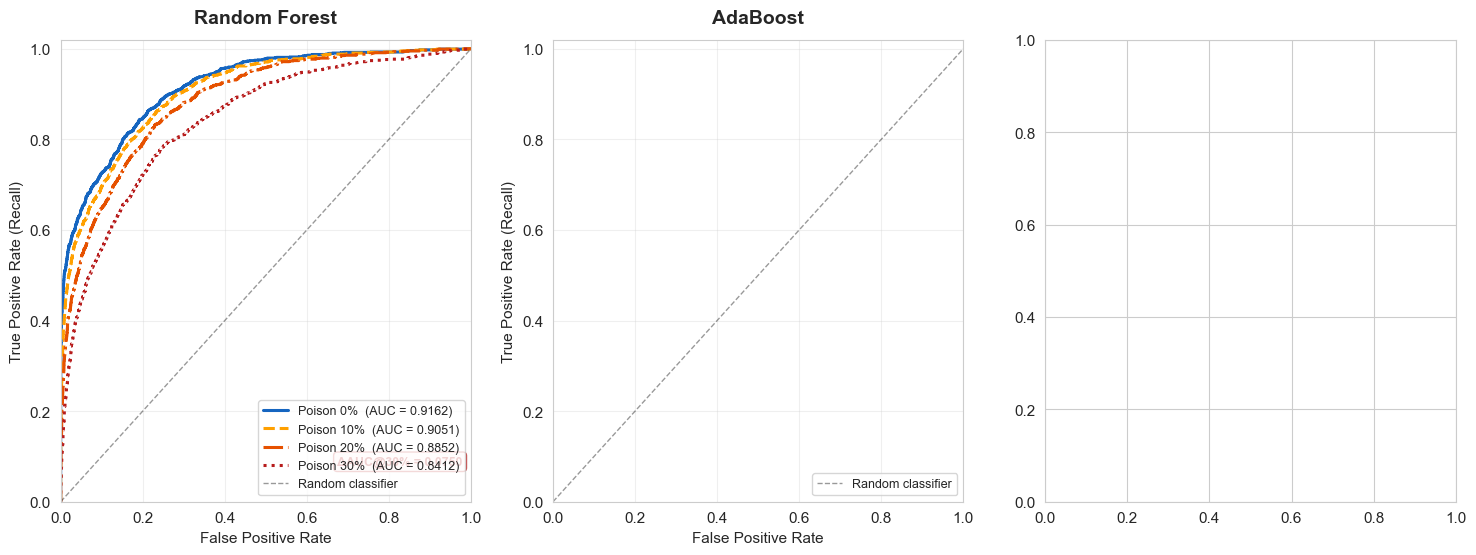

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

model_names = ['Random Forest', 'AdaBoost', 'SVM']
poison_colors = {
    '0%' : '#1565C0',
    '10%': '#FFA000',
    '20%': '#E65100',
    '30%': '#B71C1C'
}
poison_styles = {'0%': '-', '10%': '--', '20%': '-.', '30%': ':'}

for ax, model_name in zip(axes, model_names):
    model_results = [r for r in all_results if r['Model'] == model_name]

    for r in model_results:
        rate_label = r['Poison_Rate']
        fpr_arr, tpr_arr, _ = roc_curve(y_test, r['y_proba'])
        auc_val = r['AUC']

        ax.plot(fpr_arr, tpr_arr,
                color=poison_colors[rate_label],
                linestyle=poison_styles[rate_label],
                linewidth=2.2,
                label=f"Poison {rate_label}  (AUC = {auc_val:.4f})")

    # Diagonal reference line
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.4, label='Random classifier')

    ax.set_title(f'{model_name}', fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
    ax.legend(fontsize=9, loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.grid(True, alpha=0.3)

    # Annotate AUC degradation
    clean_auc  = next(r['AUC'] for r in model_results if r['Poison_Rate'] == '0%')
    worst_auc  = next(r['AUC'] for r in model_results if r['Poison_Rate'] == '30%')
    delta_auc  = round(clean_auc - worst_auc, 4)
    ax.annotate(f'ΔAUC@30% = {delta_auc:.4f}',
                xy=(0.98, 0.08), xycoords='axes fraction',
                ha='right', fontsize=9,
                color='#B71C1C', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3F3', edgecolor='#B71C1C', alpha=0.8))

plt.suptitle('ROC-AUC Curves — Shallow ML Models Under Data Poisoning\n(Each line = one poison penetration level — degradation shows robustness loss)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('processed_data/week2_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: processed_data/week2_roc_curves.png')

## Cell 8 — Confusion Matrices (Per Model, All Poison Levels)

4 confusion matrices per model — one for each poison level. Shows how the error patterns shift as poisoning increases.

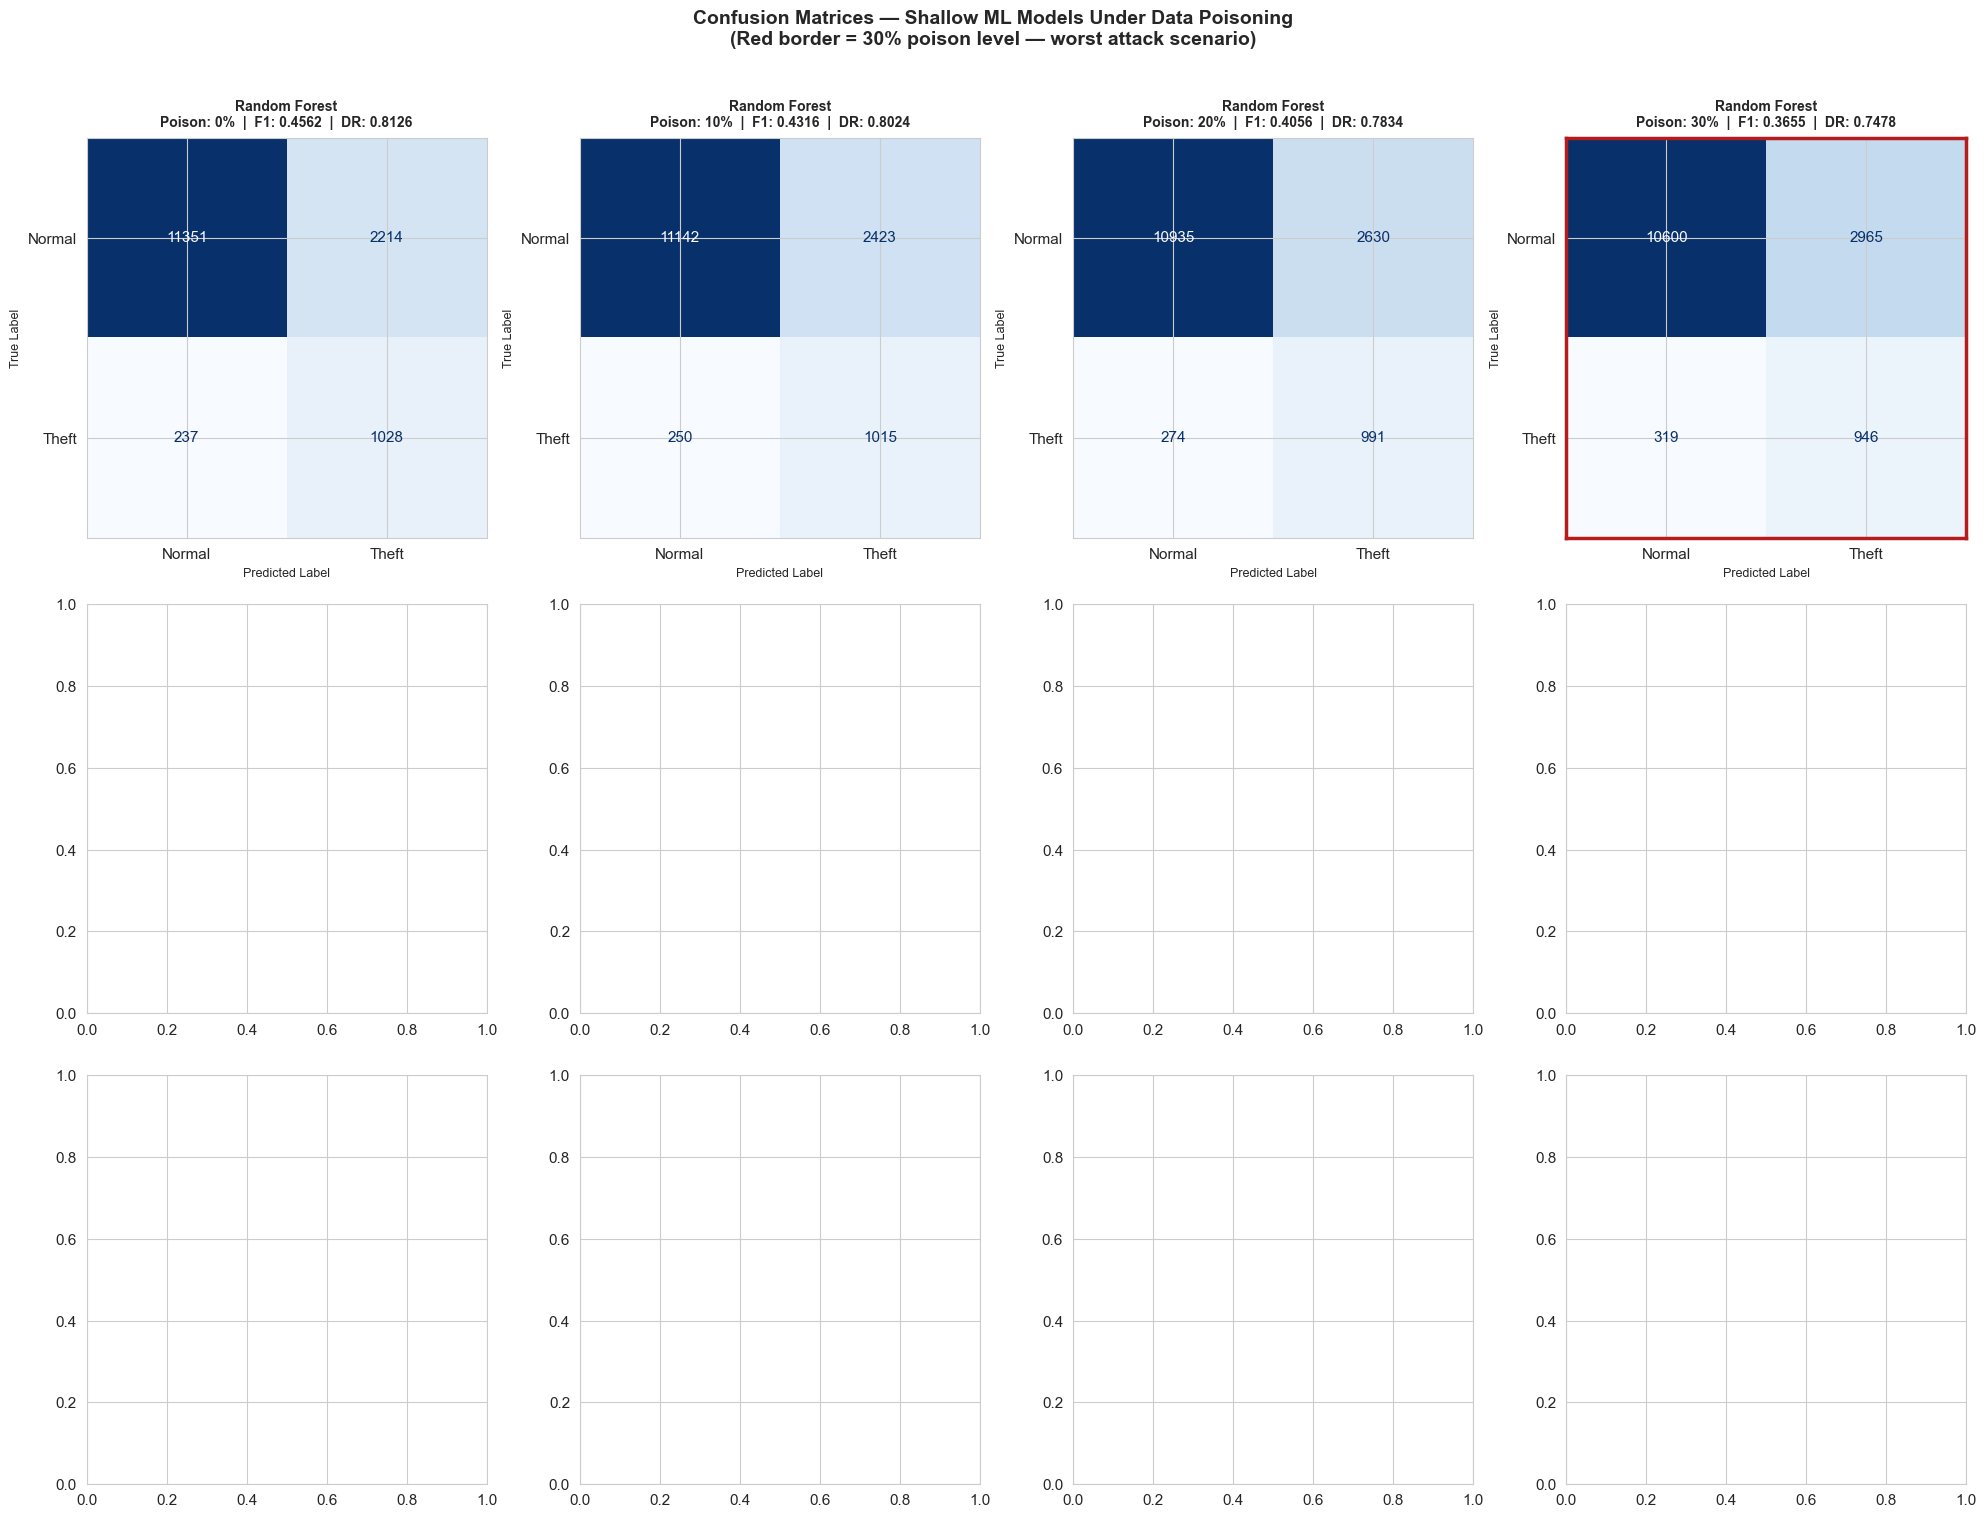

💾 Saved: processed_data/week2_confusion_matrices.png


In [21]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

model_names  = ['Random Forest', 'AdaBoost', 'SVM']
cmap_list    = ['Blues', 'Reds', 'Greens']

for row_idx, (model_name, cmap) in enumerate(zip(model_names, cmap_list)):
    model_results = [r for r in all_results if r['Model'] == model_name]

    for col_idx, r in enumerate(model_results):
        ax = axes[row_idx][col_idx]
        rate_label = r['Poison_Rate']

        cm = confusion_matrix(y_test, r['y_pred'])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Theft'])
        disp.plot(ax=ax, cmap=cmap, colorbar=False, values_format='d')

        # Title with key metrics
        ax.set_title(
            f'{model_name}\nPoison: {rate_label}  |  F1: {r["F1"]:.4f}  |  DR: {r["DR"]:.4f}',
            fontsize=10, fontweight='bold', pad=8
        )
        ax.set_xlabel('Predicted Label', fontsize=9)
        ax.set_ylabel('True Label', fontsize=9)

        # Highlight if this is the worst performing run
        if rate_label == '30%':
            for spine in ax.spines.values():
                spine.set_edgecolor('#B71C1C')
                spine.set_linewidth(2.5)

plt.suptitle('Confusion Matrices — Shallow ML Models Under Data Poisoning\n(Red border = 30% poison level — worst attack scenario)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('processed_data/week2_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: processed_data/week2_confusion_matrices.png')

## Cell 9 — Δ F1 Comparison Bar Chart

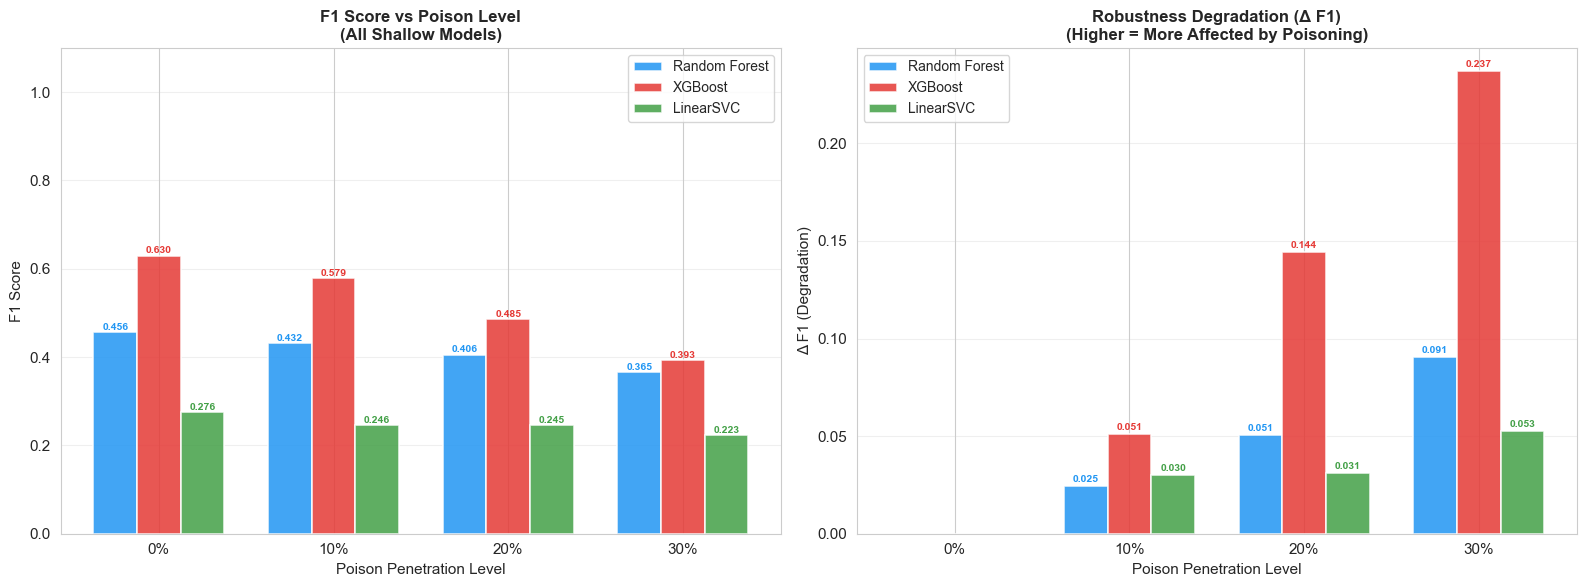

💾 Saved: processed_data/week2_delta_comparison.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: F1 score across poison levels ─────────────────────────────────
ax = axes[0]
x     = np.arange(len(POISON_LABELS))
width = 0.25
offsets = [-width, 0, width]

for i, (mname, color) in enumerate(MODEL_COLORS.items()):
    scores = [r['F1'] for r in all_results if r['Model'] == mname]
    bars = ax.bar(x + offsets[i], scores, width, label=mname,
                  color=color, alpha=0.85, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=7.5, fontweight='bold', color=color)

ax.set_xlabel('Poison Penetration Level', fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('F1 Score vs Poison Level\n(All Shallow Models)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(POISON_LABELS)
ax.legend(fontsize=10)
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

# ── Plot 2: Delta F1 at each poison level ────────────────────────────────
ax = axes[1]
for i, (mname, color) in enumerate(MODEL_COLORS.items()):
    model_res = [r for r in all_results if r['Model'] == mname]
    clean_f1  = next(r['F1'] for r in model_res if r['Poison_Rate'] == '0%')
    deltas    = [round(clean_f1 - r['F1'], 4) for r in model_res]
    bars = ax.bar(x + offsets[i], deltas, width, label=mname,
                  color=color, alpha=0.85, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, deltas):
        if val > 0.001:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{val:.3f}', ha='center', fontsize=7.5, fontweight='bold', color=color)

ax.set_xlabel('Poison Penetration Level', fontsize=11)
ax.set_ylabel('Δ F1 (Degradation)', fontsize=11)
ax.set_title('Robustness Degradation (Δ F1)\n(Higher = More Affected by Poisoning)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(POISON_LABELS)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('processed_data/week2_delta_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: processed_data/week2_delta_comparison.png')

## Cell 10 — AUC Degradation Line Plot

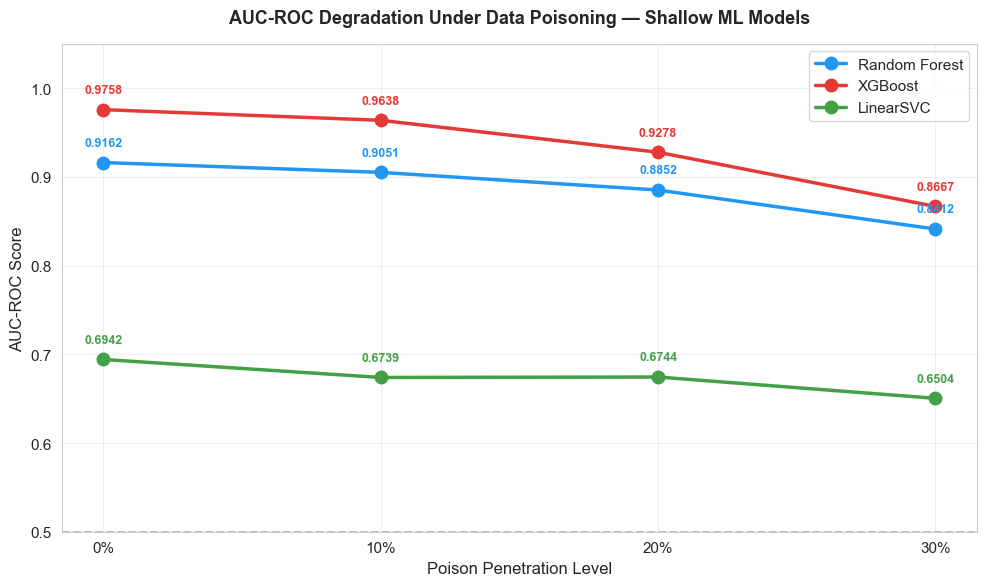

💾 Saved: processed_data/week2_auc_degradation.png


In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

for mname, color in MODEL_COLORS.items():
    model_res = [r for r in all_results if r['Model'] == mname]
    auc_vals  = [r['AUC'] for r in model_res]

    ax.plot(POISON_LABELS, auc_vals,
            marker='o', markersize=9,
            linewidth=2.5, color=color, label=mname)

    # Annotate each point
    for x_pos, (label, val) in enumerate(zip(POISON_LABELS, auc_vals)):
        ax.annotate(f'{val:.4f}',
                    xy=(x_pos, val),
                    xytext=(0, 12), textcoords='offset points',
                    ha='center', fontsize=9, color=color, fontweight='bold')

ax.set_xlabel('Poison Penetration Level', fontsize=12)
ax.set_ylabel('AUC-ROC Score', fontsize=12)
ax.set_title('AUC-ROC Degradation Under Data Poisoning — Shallow ML Models',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.set_ylim([0.5, 1.05])
ax.grid(True, alpha=0.3)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random classifier (AUC=0.5)')

plt.tight_layout()
plt.savefig('processed_data/week2_auc_degradation.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: processed_data/week2_auc_degradation.png')

## Cell 11 — Detection Rate (DR) Degradation Line Plot

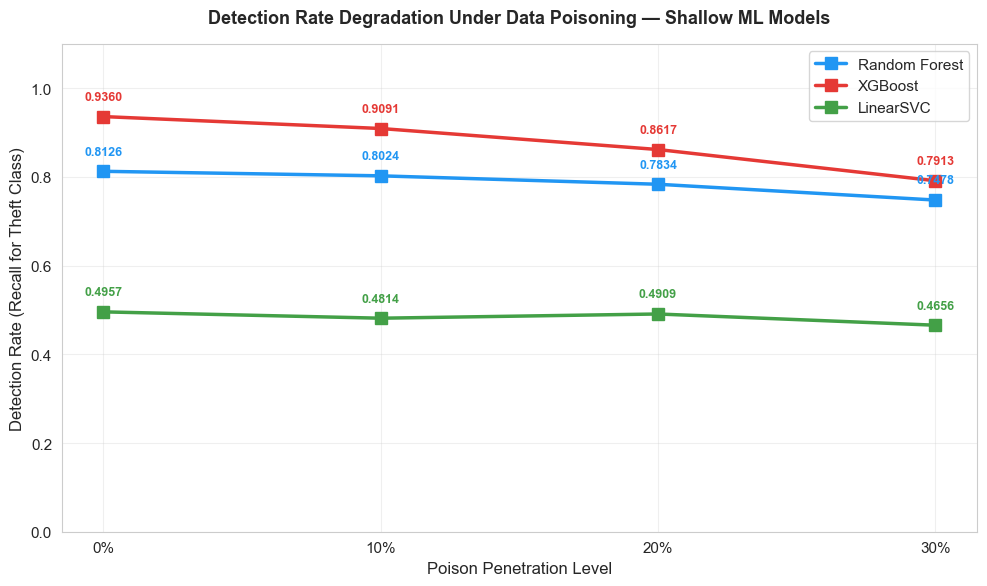

💾 Saved: processed_data/week2_dr_degradation.png


In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

for mname, color in MODEL_COLORS.items():
    model_res = [r for r in all_results if r['Model'] == mname]
    dr_vals   = [r['DR'] for r in model_res]

    ax.plot(POISON_LABELS, dr_vals,
            marker='s', markersize=9,
            linewidth=2.5, color=color, label=mname)

    for x_pos, val in enumerate(dr_vals):
        ax.annotate(f'{val:.4f}',
                    xy=(x_pos, val),
                    xytext=(0, 12), textcoords='offset points',
                    ha='center', fontsize=9, color=color, fontweight='bold')

ax.set_xlabel('Poison Penetration Level', fontsize=12)
ax.set_ylabel('Detection Rate (Recall for Theft Class)', fontsize=12)
ax.set_title('Detection Rate Degradation Under Data Poisoning — Shallow ML Models',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('processed_data/week2_dr_degradation.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: processed_data/week2_dr_degradation.png')

## Cell 12 — Week 2 Summary

In [ ]:
print('=' * 65)
print('  WEEK 2 COMPLETE — SHALLOW ML SUMMARY')
print('=' * 65)

for mname in ['Random Forest', 'AdaBoost', 'SVM']:
    model_res  = [r for r in all_results if r['Model'] == mname]
    clean      = next(r for r in model_res if r['Poison_Rate'] == '0%')
    worst      = next(r for r in model_res if r['Poison_Rate'] == '30%')
    delta_f1   = round(clean['F1']  - worst['F1'],  4)
    delta_auc  = round(clean['AUC'] - worst['AUC'], 4)
    delta_dr   = round(clean['DR']  - worst['DR'],  4)

    print(f'\n  {mname}')
    print(f'    Clean  F1={clean["F1"]:.4f}  AUC={clean["AUC"]:.4f}  DR={clean["DR"]:.4f}')
    print(f'    @30%   F1={worst["F1"]:.4f}  AUC={worst["AUC"]:.4f}  DR={worst["DR"]:.4f}')
    print(f'    Δ F1={delta_f1:+.4f}  Δ AUC={delta_auc:+.4f}  Δ DR={delta_dr:+.4f}')

print()
print('  Files saved:')
files = [
    'week2_shallow_results.csv',
    'week2_delta_f1.csv',
    'week2_roc_curves.png',
    'week2_confusion_matrices.png',
    'week2_delta_comparison.png',
    'week2_auc_degradation.png',
    'week2_dr_degradation.png',
]
for f in files:
    print(f'    ✅  /Users/sundar.g/Documents/projects folder/ElectricityTheftDetection/processed_data/{f}')

print()
print('  Next: Week3_Deep_Learning_Models.ipynb')
print('=' * 65)